# Reinforcement Learning for Pick and Place Tasks

**Objective:** In this notebook, we will learn the fundamental pipeline of path planning:
1.  **Map Processing:** Loading a map image and converting it into an **Occupancy Grid**.
2.  **Configuration Space:** Inflating obstacles to account for the robot's size.
3.  **Global Planning:** Finding a path from Start to Goal using planning algorithms.

In [1]:
# Installation prerrequisites
!pip install stable-baselines3
!pip install pybullet
!pip install numpy
!pip install matplotlib
!pip install imageio-ffmpeg


!git clone https://github.com/Mobile-Robots-Group-UC3M/ReinforcementLearningPickPlace.git
%cd ReinforcementLearningPickPlace

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.8/116.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 8.6 MB/s eta 0:00:00
Cloning into 'PathPlanningAlgorithms'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 2), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 102.19 KiB | 10.22 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/PathPlanningAlgo

In [2]:
# Importing necessary libraries
from ur5_env import  UR5RobotiqEnv
from stable_baselines3 import PPO, SAC,A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import CheckpointCallback
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Train algorithms for training

Robots usually use **Occupancy Grid Maps**. These are essentially discretized grids where each cell represents a specific area in the world.
* **Image:** A grayscale image where dark pixels are obstacles and light pixels are free space.
* **Metadata:** Contains the real-world resolution (meters per pixel) and origin coordinates.

In [3]:
def train_algo():
    # Create a directory to store the log files if it doesn't exist
    log_dir = "./logs"
    if not os.path.exists(log_dir):  # Check if the directory exists
        os.makedirs(log_dir)  # Create the directory if it doesn't exist

    # Wrap the environment with the Monitor to record the results
    env = UR5RobotiqEnv()  # Instantiate the custom driving environment
    env = Monitor(env, log_dir)  # Monitor the environment and store logs in the specified directory

    # Predefine the algorithm to use (PPO, SAC, or A2C)
    algo_name = "SAC"  # Set the algorithm to use (SAC, PPO, or A2C)
    if algo_name == "PPO":
        model = PPO("MlpPolicy", env, verbose=1)  # Choose PPO if specified
    elif algo_name == "SAC":
        model = SAC("MlpPolicy", env, verbose=1)  # Choose SAC if specified
    elif algo_name == "A2C":
        model = A2C("MlpPolicy", env, verbose=1)  # Choose A2C if specified
    else:
        raise ValueError("Invalid algorithm name. Please choose 'PPO', 'SAC', or 'A2C'.")  # Raise an error if an invalid algorithm is specified

    # Set up a checkpoint callback to save models periodically
    checkpoint_callback = CheckpointCallback(save_freq=1000, save_path="./models", name_prefix=f"ur_robot_{algo_name.lower()}")

    # Train the model for a total of 10000 timesteps and save checkpoints
    model.learn(total_timesteps=10000, callback=checkpoint_callback)

    # Save the trained model
    model.save(f"ur_robot_{algo_name.lower()}")

def test_algo():
    # Initialize the environment
    env = UR5RobotiqEnv()  # Instantiate the custom driving environment
    
    # Predefine the algorithm to use (PPO, SAC, or A2C)
    algo_name = "SAC"  # Set the algorithm to use (SAC, PPO, or A2C)
    if algo_name == "PPO":
        model = PPO("MlpPolicy", env, verbose=1)  # Choose PPO if specified
    elif algo_name == "SAC":
        model = SAC("MlpPolicy", env, verbose=1)  # Choose SAC if specified
    elif algo_name == "A2C":
        model = A2C("MlpPolicy", env, verbose=1)  # Choose A2C if specified
    else:
        raise ValueError("Invalid algorithm name. Please choose 'PPO', 'SAC', or 'A2C'.")  # Raise an error if an invalid algorithm is specified

    # Load the trained model
    model = model.load(f"./models/ur_robot_{algo_name.lower()}_7000_steps")

    # Reset the environment and get the initial observation
    obs, info = env.reset()

    # Test the trained model
    while True:
        # Use the model to predict the next action based on the current observation
        action, _ = model.predict(obs, deterministic=True)
        
        # Sleep for 1/300 seconds to control the speed of the simulation
        time.sleep(1/300)
        
        # Execute the action and get the next state
        obs, reward, terminated, truncated, info = env.step(action)
        
        # If the environment reaches termination or truncation, reset it
        if terminated or truncated:
            obs, info = env.reset()

## 2. Reward function

We interpret the image pixel intensities. We threshold the image to define what is an obstacle and what is free.

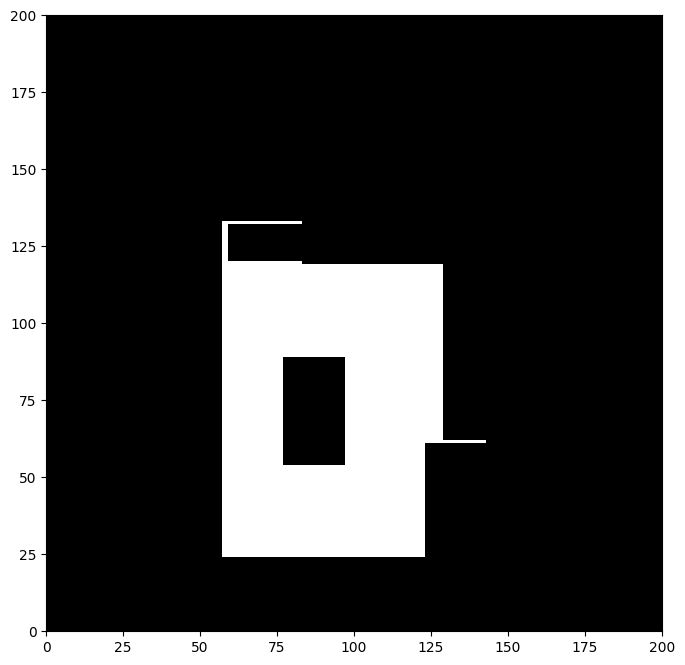

In [4]:
# Function to plot the training reward data
def plot_reward_data():
    # Set the directory for storing Monitor log files
    log_dir = "./logs"
    files = {
        "PPO": "monitor_ppo.csv",
        "A2C": "monitor_a2c.csv",
        "SAC": "monitor_sac.csv"
    }

    # Create a plot for the rewards over time
    plt.figure(figsize=(12, 6))

    # Iterate through the files for each algorithm
    for label, file_name in files.items():
        monitor_file = os.path.join(log_dir, file_name)
        
        # Read the Monitor log data (skip the first row of comments)
        data = pd.read_csv(monitor_file, skiprows=1)
        
        # Calculate the cumulative timestep
        data['timestep'] = np.cumsum(data['l'])  # Accumulate the timestep, as global timestep

        data['timestep'] -= data['timestep'].iloc[0]  
        
        # Apply smoothing to the reward data
        smoothed_rewards = smooth(data['r'])
        
        # Plot the smoothed rewards against the timestep
        plt.plot(
            data['timestep'][:len(smoothed_rewards)], 
            smoothed_rewards, 
            label=label
        )
    
    # Add labels and title to the plot
    plt.xlabel("Step")
    plt.ylabel("Reward")
    plt.title("Training Reward")
    
    # Add legend to the plot
    plt.legend()
    plt.grid()  # Display grid lines
    plt.show()  # Show the plot
    
def smooth(data, window_size=10):
    """Apply weighted moving average smoothing to the data"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

## 3. Main loop

A robot is not a single point; it has a physical radius. If we plan a path right next to a wall for a point, a real robot will crash into the wall.

To solve this, we transform the map into **Configuration Space (C-Space)**. We "inflate" the obstacles by the radius of the robot.

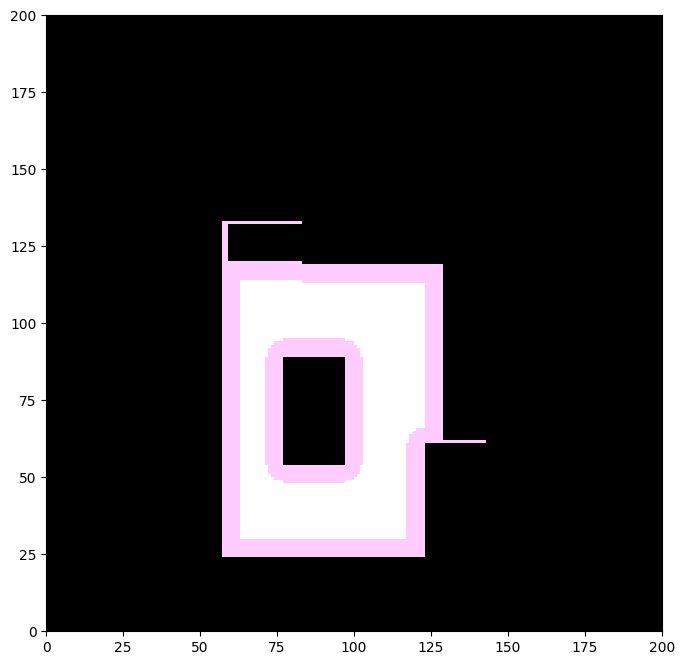

In [5]:
# Main entry point for the script
if __name__ == '__main__':
    main()  # Run the main function to either train or test the model
    # plot_reward_data()  # Plot the training reward data